In [1]:
from google.colab import files

uploaded = files.upload()

Saving synthetic_industrial_machine_data.csv to synthetic_industrial_machine_data.csv


In [2]:
import pandas as pd

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (219000, 22)


,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,temp_bearing_degC,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag,wo_type
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,63.3,63.5,4.944,3.886,3.71,85.9,1794,16.09,0,NaN
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.0,64.8,4.614,3.530,3.67,82.0,1790,15.53,0,NaN
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.4,66.7,4.360,2.976,3.74,83.0,1827,16.20,0,NaN
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.5,68.1,4.522,3.315,3.90,82.9,1811,16.47,0,NaN
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,62.2,66.3,4.340,3.434,3.71,80.1,1810,15.08,0,NaN


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Columns:
['transaction_date', 'asset_tag', 'machine_type', 'plant_code', 'part_no', 'part_description', 'part_family', 'criticality', 'uom', 'unit_cost_inr', 'qty_issued', 'issue_value_inr', 'temp_bearing_degC', 'temp_motor_degC', 'vibration_h_mms', 'vibration_v_mms', 'oil_pressure_bar', 'load_pct', 'shaft_rpm', 'power_consumption_kw', 'breakdown_flag', 'wo_type']

Missing Values:
transaction_date             0
asset_tag                    0
machine_type                 0
plant_code                   0
part_no                      0
part_description             0
part_family                  0
criticality                  0
uom                          0
unit_cost_inr                0
qty_issued                   0
issue_value_inr              0
temp_bearing_degC            0
temp_motor_degC              0
vibration_h_mms              0
vibration_v_mms              0
oil_pressure_bar             0
load_pct                     0
shaft_rpm                    0
power_consumption_kw       

In [4]:
# Convert transaction_date into datetime format
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Remove wo_type because it contains a large number of missing values
df = df.drop(columns=["wo_type"])

# Check the dataset after cleaning
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (219000, 21)

Missing Values:
0

Duplicate Rows: 0

Data Types:
transaction_date        datetime64[ns]
asset_tag                       object
machine_type                    object
plant_code                      object
part_no                         object
part_description                object
part_family                     object
criticality                     object
uom                             object
unit_cost_inr                    int64
qty_issued                       int64
issue_value_inr                  int64
temp_bearing_degC              float64
temp_motor_degC                float64
vibration_h_mms                float64
vibration_v_mms                float64
oil_pressure_bar               float64
load_pct                       float64
shaft_rpm                        int64
power_consumption_kw           float64
breakdown_flag                   int64
dtype: object


In [5]:
print(df["breakdown_flag"].value_counts())

breakdown_rate = df["breakdown_flag"].mean() * 100

print("Overall Breakdown Rate:", round(breakdown_rate, 2), "%")

breakdown_flag
0    197364
1     21636
Name: count, dtype: int64
Overall Breakdown Rate: 9.88 %


In [6]:
machine_summary = df.groupby("asset_tag").agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

machine_summary["Breakdown_Rate"] = machine_summary["Breakdown_Rate"] * 100

machine_summary = machine_summary.sort_values(
    "Breakdown_Rate", ascending=False
)

display(machine_summary.head(10))

,asset_tag,Total_Records,Breakdowns,Breakdown_Rate
2,AST-2017,21900,2647,12.086758
8,AST-5003,21900,2565,11.712329
6,AST-4055,21900,2558,11.680365
3,AST-2031,21900,2311,10.552511
7,AST-4061,21900,2102,9.598174
0,AST-1041,21900,2071,9.456621
4,AST-3008,21900,2002,9.141553
1,AST-1042,21900,1911,8.726027
5,AST-3019,21900,1736,7.926941
9,AST-5007,21900,1733,7.913242


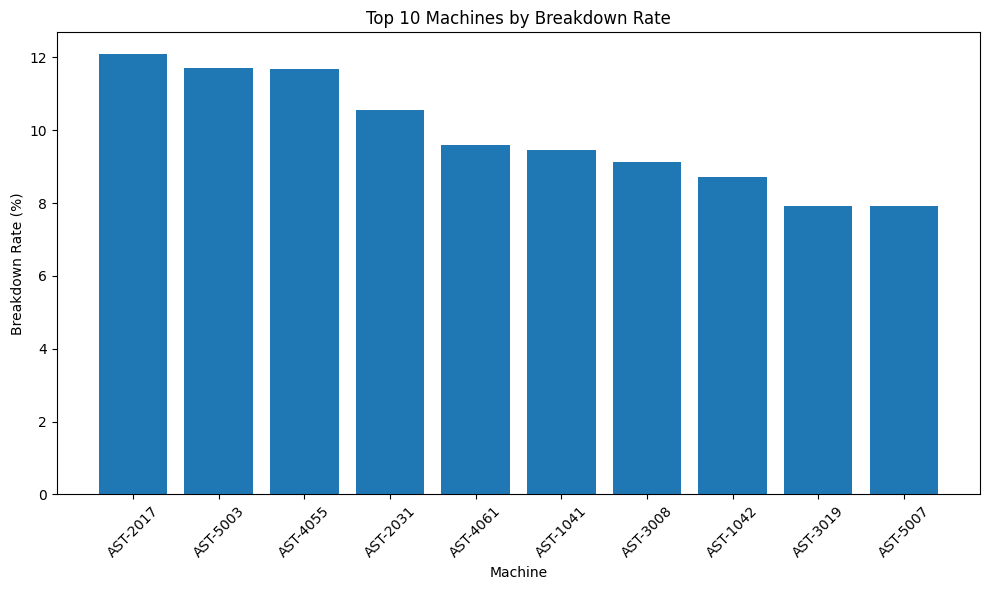

In [7]:
import matplotlib.pyplot as plt

top_machines = machine_summary.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_machines["asset_tag"], top_machines["Breakdown_Rate"])
plt.xlabel("Machine")
plt.ylabel("Breakdown Rate (%)")
plt.title("Top 10 Machines by Breakdown Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
part_summary = df.groupby("part_family").agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

part_summary["Breakdown_Rate"] = part_summary["Breakdown_Rate"] * 100

part_summary = part_summary.sort_values(
    "Breakdown_Rate", ascending=False
)

display(part_summary)

,part_family,Total_Records,Breakdowns,Breakdown_Rate
0,Bearing,32850,4221,12.849315
8,Sensor,21900,2454,11.205479
3,Electrical,21900,2417,11.036530
5,Filter,21900,2136,9.753425
2,Drive Belt,21900,2134,9.744292
7,Seal & Gasket,32850,3118,9.491629
1,Coupling,21900,1987,9.073059
4,Fastener,21900,1626,7.424658
6,Lubrication,21900,1543,7.045662


In [9]:
temp_bins = pd.cut(
    df["temp_motor_degC"],
    bins=5
)

temp_summary = df.groupby(temp_bins, observed=True).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

temp_summary["Breakdown_Rate"] *= 100

display(temp_summary)

,temp_motor_degC,Total_Records,Breakdowns,Breakdown_Rate
0,"(49.761, 57.52]",2380,150,6.302521
1,"(57.52, 65.24]",54240,5150,9.494838
2,"(65.24, 72.96]",66460,6973,10.492025
3,"(72.96, 80.68]",79860,7581,9.492863
4,"(80.68, 88.4]",16060,1782,11.095890


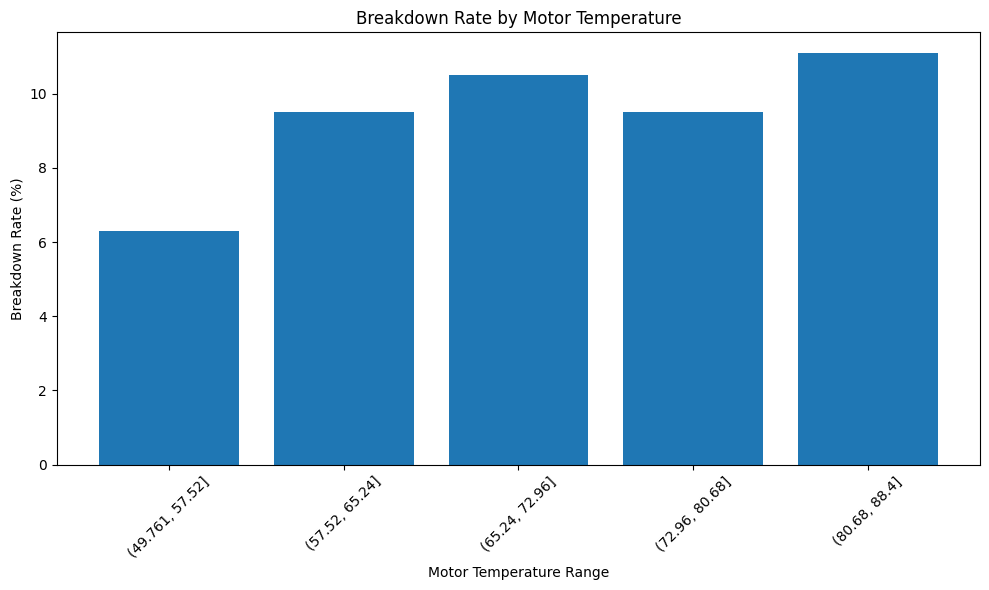

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    temp_summary["temp_motor_degC"].astype(str),
    temp_summary["Breakdown_Rate"]
)

plt.xlabel("Motor Temperature Range")
plt.ylabel("Breakdown Rate (%)")
plt.title("Breakdown Rate by Motor Temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
pressure_bins = pd.qcut(
    df["oil_pressure_bar"],
    q=5,
    duplicates="drop"
)

pressure_summary = df.groupby(pressure_bins, observed=True).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

pressure_summary["Breakdown_Rate"] *= 100

display(pressure_summary)

,oil_pressure_bar,Total_Records,Breakdowns,Breakdown_Rate
0,"(3.299, 4.03]",45160,4081,9.036758
1,"(4.03, 4.79]",42760,3911,9.146399
2,"(4.79, 5.08]",43660,4261,9.759505
3,"(5.08, 5.852]",43620,4498,10.311784
4,"(5.852, 7.39]",43800,4885,11.152968


In [12]:
machine_type_summary = df.groupby("machine_type").agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

machine_type_summary["Breakdown_Rate"] *= 100

machine_type_summary = machine_type_summary.sort_values(
    "Breakdown_Rate", ascending=False
)

display(machine_type_summary)

,machine_type,Total_Records,Breakdowns,Breakdown_Rate
3,Hydraulic Press,43800,4958,11.319635
4,Screw Compressor,43800,4660,10.639269
2,EOT Crane,43800,4298,9.812785
1,CNC Lathe,43800,3982,9.091324
0,Belt Conveyor,43800,3738,8.534247


In [13]:
vibration_bins = pd.qcut(
    df["vibration_h_mms"],
    q=5,
    duplicates="drop"
)

vibration_summary = df.groupby(vibration_bins, observed=True).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

vibration_summary["Breakdown_Rate"] *= 100

display(vibration_summary)

,vibration_h_mms,Total_Records,Breakdowns,Breakdown_Rate
0,"(0.67, 2.962]",43860,3550,8.093935
1,"(2.962, 3.401]",43800,4207,9.605023
2,"(3.401, 3.905]",43740,4567,10.441244
3,"(3.905, 4.577]",43800,4483,10.235160
4,"(4.577, 13.305]",43800,4829,11.025114


In [14]:
df["temp_group"] = pd.qcut(
    df["temp_motor_degC"],
    q=4,
    duplicates="drop"
)

combination_summary = df.groupby(
    ["machine_type", "temp_group"],
    observed=True
).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

combination_summary["Breakdown_Rate"] *= 100

combination_summary = combination_summary[
    combination_summary["Total_Records"] >= 100
].sort_values(
    "Breakdown_Rate",
    ascending=False
)

display(combination_summary.head(10))

,machine_type,temp_group,Total_Records,Breakdowns,Breakdown_Rate
18,Screw Compressor,"(71.5, 77.0]",6180,893,14.449838
15,Hydraulic Press,"(77.0, 88.4]",16600,2157,12.993976
1,Belt Conveyor,"(65.1, 71.5]",2980,346,11.610738
9,EOT Crane,"(65.1, 71.5]",2840,326,11.478873
8,EOT Crane,"(49.799, 65.1]",20220,2295,11.350148
17,Screw Compressor,"(65.1, 71.5]",24440,2723,11.141571
14,Hydraulic Press,"(71.5, 77.0]",20800,2236,10.750000
7,CNC Lathe,"(77.0, 88.4]",10780,1107,10.269017
5,CNC Lathe,"(65.1, 71.5]",18040,1770,9.811530
11,EOT Crane,"(77.0, 88.4]",6440,617,9.580745


In [15]:
features = [
    "machine_type",
    "plant_code",
    "part_family",
    "criticality",
    "temp_bearing_degC",
    "temp_motor_degC",
    "vibration_h_mms",
    "vibration_v_mms",
    "oil_pressure_bar",
    "load_pct",
    "shaft_rpm",
    "power_consumption_kw"
]

X = df[features]
y = df["breakdown_flag"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (175200, 12)
Testing Shape: (43800, 12)


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "machine_type",
    "plant_code",
    "part_family",
    "criticality"
]

numerical_features = [
    "temp_bearing_degC",
    "temp_motor_degC",
    "vibration_h_mms",
    "vibration_v_mms",
    "oil_pressure_bar",
    "load_pct",
    "shaft_rpm",
    "power_consumption_kw"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['machine_type', 'plant_code',
                                                   'part_family',
                                                   'criticality']),
                                                 ('num', 'passthrough',
                                                  ['temp_bearing_degC',
                                                   'temp_motor_degC',
                                                   'vibration_h_mms',
                                                   'vibration_v_mms',
                                                   'oil_pressure_bar',
                                                   'load_pct', 'shaft_rpm',
                                                   'power_consumption_kw'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=150, n_jobs=-1,
                                        random_state=42))])

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

Accuracy: 0.8574
Precision: 0.1602
Recall: 0.1045
F1 Score: 0.1265


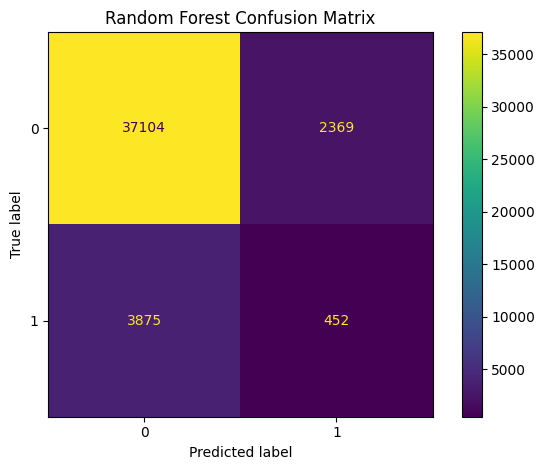

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
rf = model.named_steps["classifier"]
encoder = model.named_steps["preprocessor"]

feature_names = encoder.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
25,num__load_pct,0.140545
26,num__shaft_rpm,0.138957
27,num__power_consumption_kw,0.119374
22,num__vibration_h_mms,0.091059
23,num__vibration_v_mms,0.089876
20,num__temp_bearing_degC,0.087754
24,num__oil_pressure_bar,0.087279
21,num__temp_motor_degC,0.087190
15,cat__part_family_Seal & Gasket,0.020303
16,cat__part_family_Sensor,0.016212


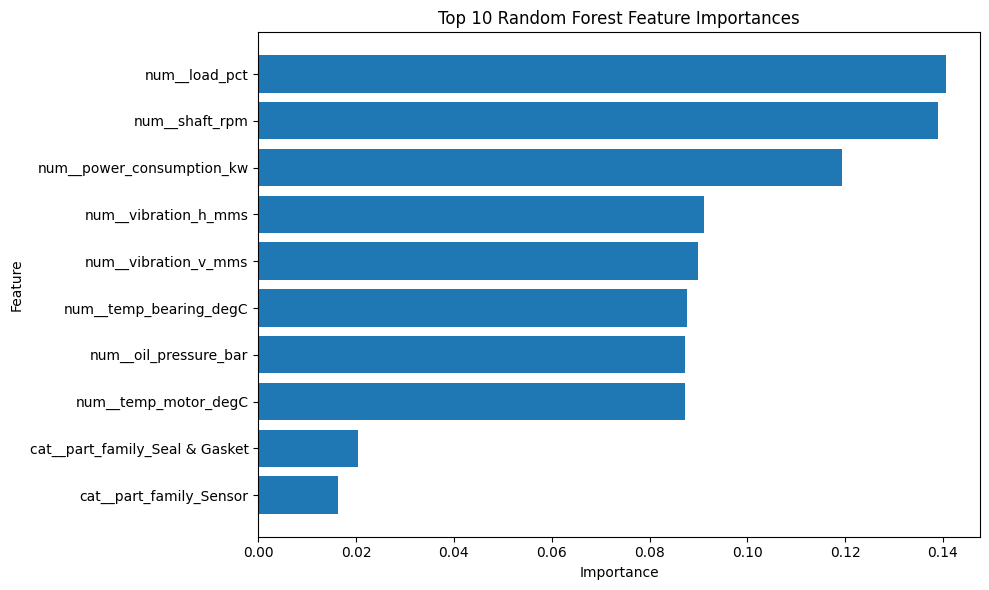

In [22]:
top_features = importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

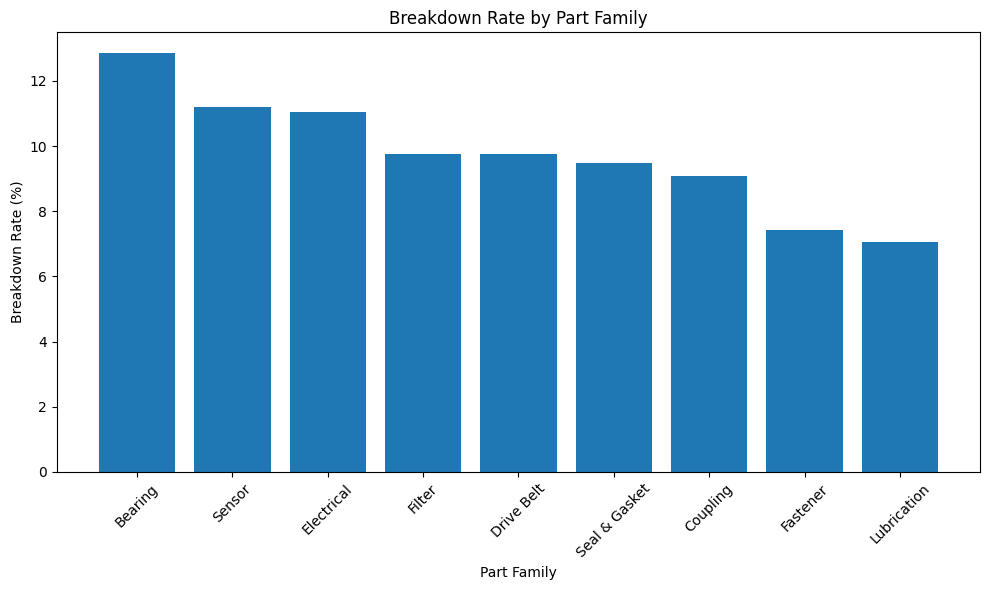

In [23]:
top_parts = part_summary.head(10)

plt.figure(figsize=(10, 6))
plt.bar(
    top_parts["part_family"],
    top_parts["Breakdown_Rate"]
)
plt.xlabel("Part Family")
plt.ylabel("Breakdown Rate (%)")
plt.title("Breakdown Rate by Part Family")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[37104  2369]
 [ 3875   452]]
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     39473
           1       0.16      0.10      0.13      4327

    accuracy                           0.86     43800
   macro avg       0.53      0.52      0.52     43800
weighted avg       0.83      0.86      0.84     43800



In [25]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.30

y_pred_tuned = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, y_pred_tuned))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     39473
           1       0.17      0.15      0.16      4327

    accuracy                           0.84     43800
   macro avg       0.54      0.53      0.53     43800
weighted avg       0.83      0.84      0.84     43800



In [26]:
print(confusion_matrix(y_test, y_pred_tuned))

[[36255  3218]
 [ 3687   640]]


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    pred = (y_prob >= threshold).astype(int)

    print(
        "Threshold:", threshold,
        "| Accuracy:", round(accuracy_score(y_test, pred), 4),
        "| Precision:", round(precision_score(y_test, pred), 4),
        "| Recall:", round(recall_score(y_test, pred), 4),
        "| F1:", round(f1_score(y_test, pred), 4)
    )

Threshold: 0.25 | Accuracy: 0.8275 | Precision: 0.1663 | Recall: 0.1858 | F1: 0.1755
Threshold: 0.3 | Accuracy: 0.8424 | Precision: 0.1659 | Recall: 0.1479 | F1: 0.1564
Threshold: 0.35 | Accuracy: 0.8511 | Precision: 0.1659 | Recall: 0.126 | F1: 0.1432
Threshold: 0.4 | Accuracy: 0.855 | Precision: 0.1626 | Recall: 0.1128 | F1: 0.1332
Threshold: 0.45 | Accuracy: 0.8566 | Precision: 0.1606 | Recall: 0.1068 | F1: 0.1283
Threshold: 0.5 | Accuracy: 0.8574 | Precision: 0.1602 | Recall: 0.1045 | F1: 0.1265


In [28]:
rf = model.named_steps["classifier"]
encoder = model.named_steps["preprocessor"]

feature_names = encoder.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
25,num__load_pct,0.140545
26,num__shaft_rpm,0.138957
27,num__power_consumption_kw,0.119374
22,num__vibration_h_mms,0.091059
23,num__vibration_v_mms,0.089876
20,num__temp_bearing_degC,0.087754
24,num__oil_pressure_bar,0.087279
21,num__temp_motor_degC,0.087190
15,cat__part_family_Seal & Gasket,0.020303
16,cat__part_family_Sensor,0.016212


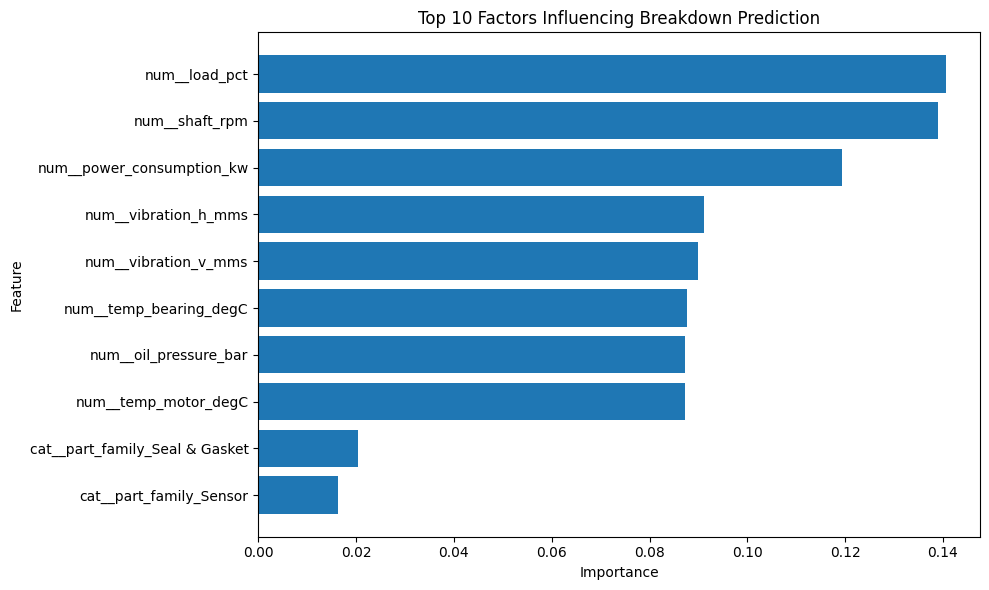

In [29]:
top_features = importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Factors Influencing Breakdown Prediction")
plt.tight_layout()
plt.show()

In [30]:
load_bins = pd.qcut(
    df["load_pct"],
    q=5,
    duplicates="drop"
)

load_summary = df.groupby(
    load_bins,
    observed=True
).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

load_summary["Breakdown_Rate"] *= 100

display(load_summary)

,load_pct,Total_Records,Breakdowns,Breakdown_Rate
0,"(34.199000000000005, 57.2]",43980,2501,5.686676
1,"(57.2, 63.8]",43720,4278,9.784995
2,"(63.8, 73.7]",44000,3053,6.938636
3,"(73.7, 80.6]",44120,5825,13.202629
4,"(80.6, 95.4]",43180,5979,13.846688


In [31]:
rpm_bins = pd.qcut(
    df["shaft_rpm"],
    q=5,
    duplicates="drop"
)

rpm_summary = df.groupby(
    rpm_bins,
    observed=True
).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

rpm_summary["Breakdown_Rate"] *= 100

display(rpm_summary)

,shaft_rpm,Total_Records,Breakdowns,Breakdown_Rate
0,"(653.999, 855.6]",43800,4298,9.812785
1,"(855.6, 1204.8]",43800,4958,11.319635
2,"(1204.8, 1560.0]",43800,3738,8.534247
3,"(1560.0, 2018.6]",43800,3982,9.091324
4,"(2018.6, 2980.0]",43800,4660,10.639269


In [32]:
power_bins = pd.qcut(
    df["power_consumption_kw"],
    q=5,
    duplicates="drop"
)

power_summary = df.groupby(
    power_bins,
    observed=True
).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

power_summary["Breakdown_Rate"] *= 100

display(power_summary)

,power_consumption_kw,Total_Records,Breakdowns,Breakdown_Rate
0,"(4.428999999999999, 10.944]",43800,3661,8.358447
1,"(10.944, 15.53]",43880,2698,6.148587
2,"(15.53, 21.244]",43720,5656,12.936871
3,"(21.244, 42.08]",43820,3694,8.429941
4,"(42.08, 82.5]",43780,5927,13.538145


In [33]:
df["load_group"] = pd.qcut(
    df["load_pct"],
    q=4,
    duplicates="drop"
)

df["temp_group"] = pd.qcut(
    df["temp_motor_degC"],
    q=4,
    duplicates="drop"
)

risk_combinations = df.groupby(
    ["machine_type", "load_group", "temp_group"],
    observed=True
).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

risk_combinations["Breakdown_Rate"] *= 100

risk_combinations = risk_combinations[
    risk_combinations["Total_Records"] >= 100
].sort_values(
    "Breakdown_Rate",
    ascending=False
)

display(risk_combinations.head(10))

,machine_type,load_group,temp_group,Total_Records,Breakdowns,Breakdown_Rate
45,Hydraulic Press,"(58.9, 68.8]","(77.0, 88.4]",3280,581,17.713415
38,EOT Crane,"(79.1, 95.4]","(65.1, 71.5]",260,46,17.692308
53,Hydraulic Press,"(79.1, 95.4]","(77.0, 88.4]",300,50,16.666667
37,EOT Crane,"(79.1, 95.4]","(49.799, 65.1]",1540,256,16.623377
34,EOT Crane,"(68.8, 79.1]","(49.799, 65.1]",11980,1960,16.360601
63,Screw Compressor,"(79.1, 95.4]","(65.1, 71.5]",5780,939,16.245675
64,Screw Compressor,"(79.1, 95.4]","(71.5, 77.0]",4020,635,15.796020
62,Screw Compressor,"(79.1, 95.4]","(49.799, 65.1]",260,41,15.769231
35,EOT Crane,"(68.8, 79.1]","(65.1, 71.5]",1480,224,15.135135
51,Hydraulic Press,"(79.1, 95.4]","(65.1, 71.5]",2260,332,14.690265


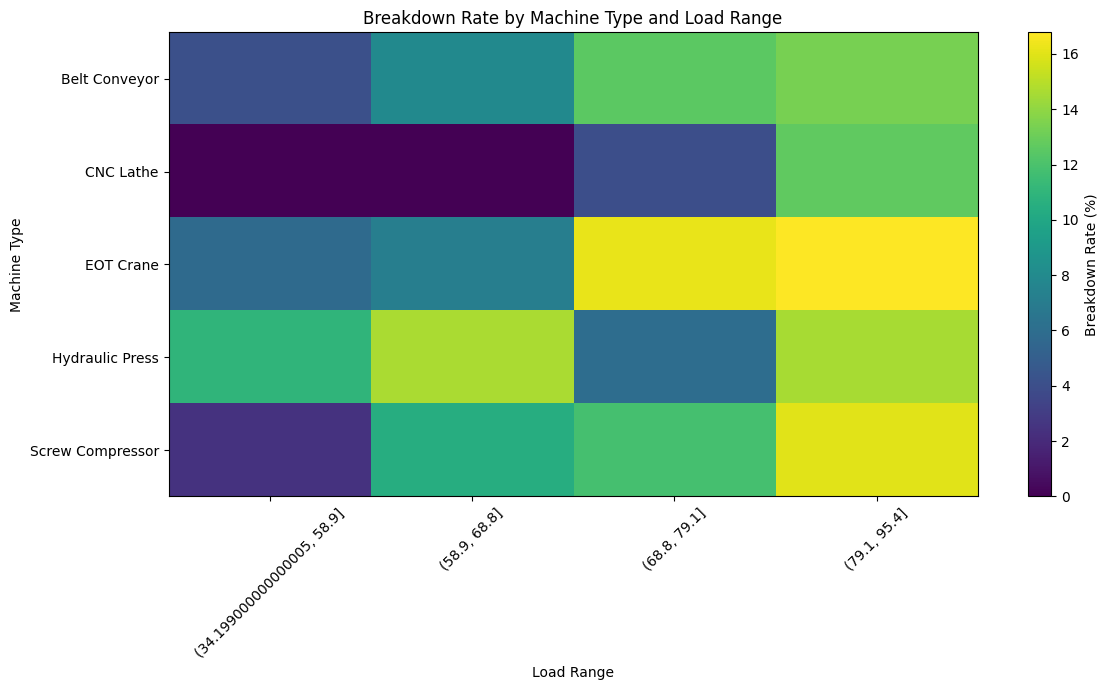

In [34]:
heatmap_data = df.groupby(
    ["machine_type", "load_group"],
    observed=True
)["breakdown_flag"].mean().unstack()

heatmap_data = heatmap_data * 100

plt.figure(figsize=(12, 7))
plt.imshow(heatmap_data, aspect="auto")

plt.xticks(
    range(len(heatmap_data.columns)),
    [str(x) for x in heatmap_data.columns],
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Load Range")
plt.ylabel("Machine Type")
plt.title("Breakdown Rate by Machine Type and Load Range")

plt.colorbar(label="Breakdown Rate (%)")
plt.tight_layout()
plt.show()

In [35]:
temp_load_summary = df.groupby(
    ["load_group", "temp_group"],
    observed=True
).agg(
    Total_Records=("breakdown_flag", "count"),
    Breakdowns=("breakdown_flag", "sum"),
    Breakdown_Rate=("breakdown_flag", "mean")
).reset_index()

temp_load_summary["Breakdown_Rate"] *= 100

temp_load_summary = temp_load_summary.sort_values(
    "Breakdown_Rate",
    ascending=False
)

display(temp_load_summary)

,load_group,temp_group,Total_Records,Breakdowns,Breakdown_Rate
12,"(79.1, 95.4]","(49.799, 65.1]",4280,641,14.976636
13,"(79.1, 95.4]","(65.1, 71.5]",21200,3029,14.287736
8,"(68.8, 79.1]","(49.799, 65.1]",24560,3492,14.218241
14,"(79.1, 95.4]","(71.5, 77.0]",19940,2780,13.941825
7,"(58.9, 68.8]","(77.0, 88.4]",16680,2077,12.452038
15,"(79.1, 95.4]","(77.0, 88.4]",8640,1068,12.361111
9,"(68.8, 79.1]","(65.1, 71.5]",16460,1561,9.483597
3,"(34.199000000000005, 58.9]","(77.0, 88.4]",26100,2275,8.716475
6,"(58.9, 68.8]","(71.5, 77.0]",6560,522,7.957317
5,"(58.9, 68.8]","(65.1, 71.5]",13660,977,7.152269


In [36]:
import joblib

model_package = {
    "model": model,
    "threshold": 0.25
}

joblib.dump(model_package, "random_forest_breakdown_model.pkl")

print("Model saved successfully")

Model saved successfully


In [37]:
from google.colab import files

files.download("random_forest_breakdown_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import sklearn
print(sklearn.__version__)

1.6.1
